In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.nn import Linear, ModuleList
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv
from torch_geometric.nn import Set2Set

import wandb

# Monkey-patch: PyTorch 1.12 doesn't support weights_only kwarg
# Guard against re-run: only patch once
# if not hasattr(torch, '_original_load'):
torch._original_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.pop('weights_only', None)
    return torch._original_load(*args, **kwargs)
torch.load = _patched_torch_load

In [3]:
DATA_ROOT = './data/models'
RAW_DIR = os.path.join(DATA_ROOT, 'raw')

df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col="SEQID")
df.sort_index(inplace=True)


print(f"Total Records: {len(df)}")
print(df.dataset.value_counts())
df.head()

Total Records: 30872
arr       27730
ov         2775
lit_uv      348
uv           19
Name: dataset, dtype: int64


,dataset,RefSeq,TargetStruct,sodium,DNA_conc,dH,Tm,dG_37
SEQID,,,,,,,,
BC1,arr,CAACCAGAAATGGTTG,((((((....)))))),0.063,NaN,-29.405457,52.382626,-1.389517
BC10,arr,CAATCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-13.860604,28.607763,0.385480
BC11,arr,CAAGCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-19.310492,32.871813,0.260496
BC15,arr,AGAAACCGAAAGGCTTCT,((((.((....)).)))),0.063,NaN,-28.359914,40.193048,-0.288995
BC16,arr,AGAATCCGAAAGGCTTCT,((((.((....)).)))),0.063,NaN,-27.266132,34.866015,0.188904


In [4]:
df_arr = df[df.dataset == 'arr']
df_ov = df[df.dataset == 'ov']
df_lit_uv = df[df.dataset == 'lit_uv']
df_uv = df[df.dataset == 'uv']

In [5]:
def calc_sumstats(df):
    """Compute min/max for dH and Tm from a dataframe. """
    """this function assums the input does not have NO nan values. """
    return {
        'dH_min' : np.min(df.dH), 'dH_max': np.max(df.dH),
        'Tm_min': np.min(df.Tm), 'Tm_max': np.max(df.Tm)
    }

In [6]:
range_arr = calc_sumstats(df_arr)
range_ov = calc_sumstats(df_ov)
range_lit_uv = calc_sumstats(df_lit_uv)
range_uv = calc_sumstats(df_uv)

In [7]:
for name, stats in zip(['arr', 'ov', 'lit_uv', 'uv'], [range_arr, range_ov, range_lit_uv, range_uv]):
    print(f"Dataset: {name}")
    print(f"  dH range: {stats['dH_min']} to {stats['dH_max']}")
    print(f"  Tm range: {stats['Tm_min']} to {stats['Tm_max']}")

Dataset: arr
  dH range: -68.20454632608892 to -2.70243642577065
  Tm range: 13.647488646379209 to 68.63588396988382
Dataset: ov
  dH range: nan to nan
  Tm range: 41.6 to 69.3
Dataset: lit_uv
  dH range: nan to nan
  Tm range: 39.1 to 88.6
Dataset: uv
  dH range: -56.82647626729113 to -23.04809725871276
  Tm range: 28.323514251703312 to 71.0105241938826


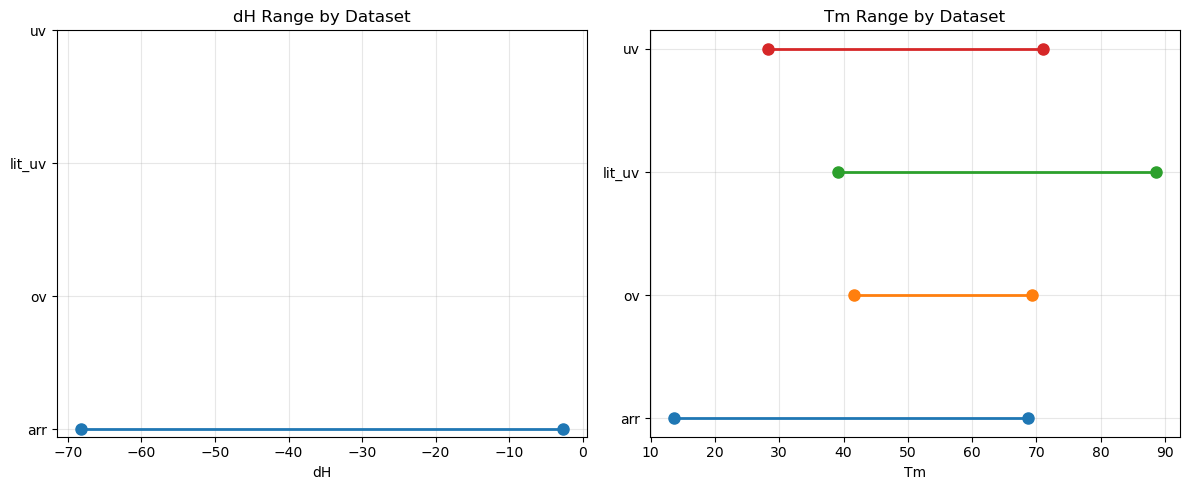

In [9]:


datasets = ['arr', 'ov', 'lit_uv', 'uv']
ranges = [range_arr, range_ov, range_lit_uv, range_uv]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (ax, dataset_name, stats) in enumerate(zip(axes, datasets, ranges)):
    # Plot dH range
    if not np.isnan(stats['dH_min']):
        ax.plot([stats['dH_min'], stats['dH_max']], [idx, idx], 'o-', linewidth=2, markersize=8, label=dataset_name)
    
axes[0].set_xlabel('dH')
axes[0].set_title('dH Range by Dataset')
axes[0].set_yticks(range(len(datasets)))
axes[0].set_yticklabels(datasets)
axes[0].grid(True, alpha=0.3)

for idx, (dataset_name, stats) in enumerate(zip(datasets, ranges)):
    axes[1].plot([stats['Tm_min'], stats['Tm_max']], [idx, idx], 'o-', linewidth=2, markersize=8)

axes[1].set_xlabel('Tm')
axes[1].set_title('Tm Range by Dataset')
axes[1].set_yticks(range(len(datasets)))
axes[1].set_yticklabels(datasets)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
seq_len_count = {"arr":[], "ov":[], "lit_uv":[], "uv":[]}
for dataset_name, df in zip(datasets, [df_arr, df_ov, df_lit_uv, df_uv]):
    for seq in df.RefSeq:
        if isinstance(seq, str):
            seq = ''.join(seq)
            seq_len_count[dataset_name].append(len(seq))
        elif isinstance(reference_sequence, str) and '[' in reference_sequence:
            reference_sequence = ''.join(eval(reference_sequence))
            seq_len_count[dataset_name].append(len(seq))
        else:
            print(f"Some RefSeq entries in {dataset_name} are not strings.")

for dataset_name in datasets:
    print(f"{dataset_name}: min length = {min(seq_len_count[dataset_name])}, max length = {max(seq_len_count[dataset_name])}")

arr: min length = 11, max length = 24
ov: min length = 46, max length = 46
lit_uv: min length = 40, max length = 68
uv: min length = 16, max length = 16


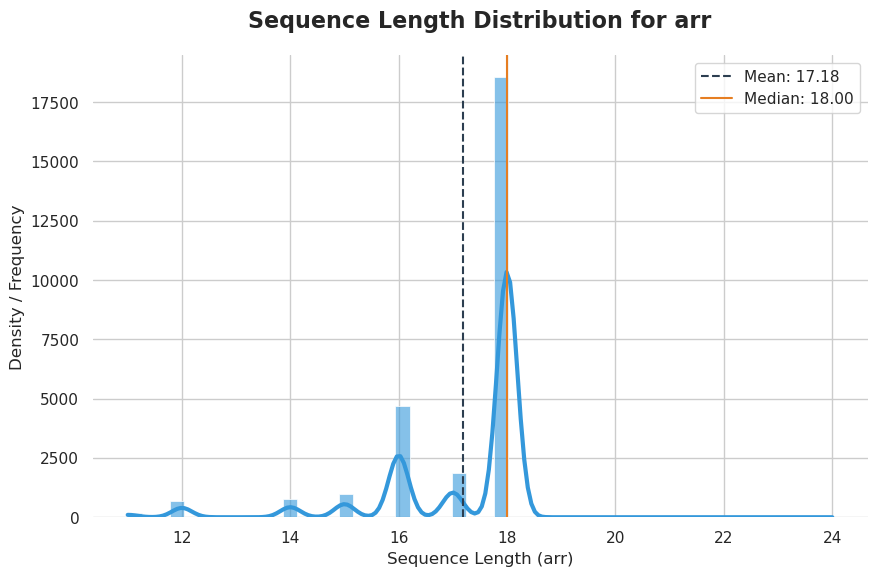

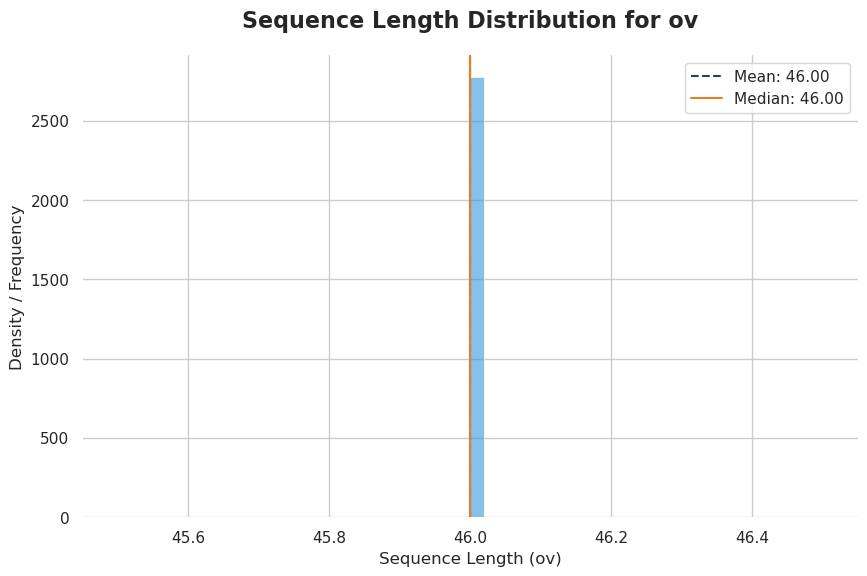

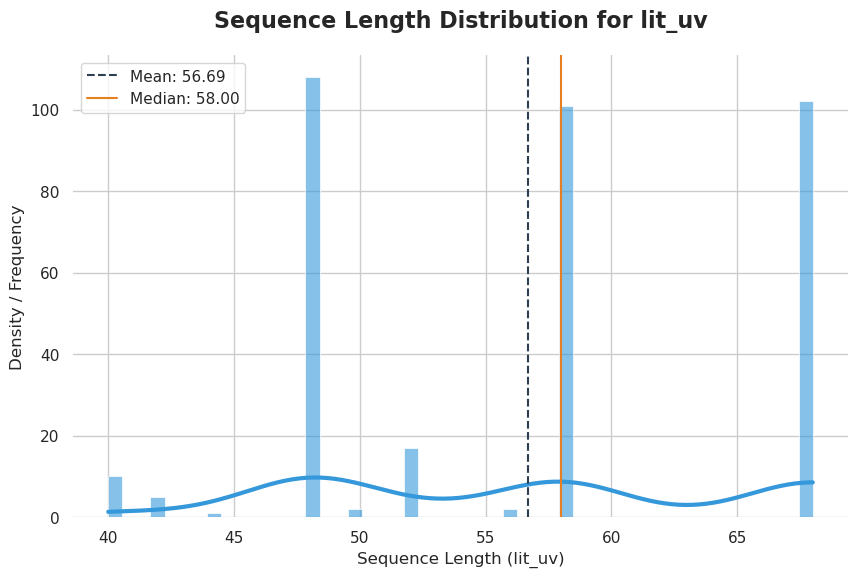

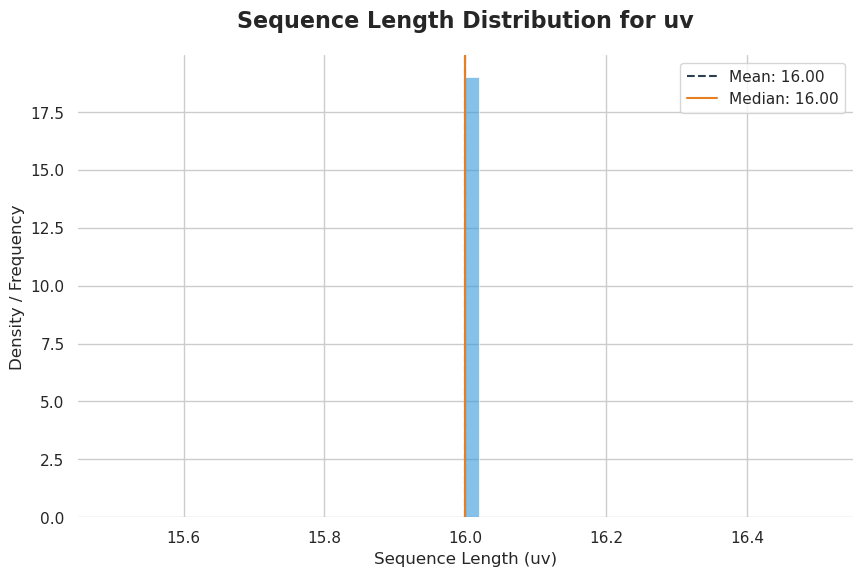

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import io
import base64

def plot_histogram(seq, dataset_name, title, y_label='Frequency', x_label='Sequence Length'):
    # plt.hist(seq, bins=50, edgecolor='black')
    # plt.xlabel(f'Length of Sequences in {dataset_name}')
    # plt.ylabel('Frequency')
    # plt.title(title)
    # plt.show()

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Create the distribution plot (Histogram + KDE)
    # Using a gradient-like color (magma/viridis-ish)
    ax = sns.histplot(
        seq, 
        bins=50, 
        kde=True, 
        color="#3498db", 
        edgecolor='white', 
        linewidth=0.5,
        alpha=0.6,
        line_kws={"color": "#e74c3c", "lw": 3}
    )
    
    # Add vertical lines for mean and median
    mean_val = np.mean(seq)
    median_val = np.median(seq)
    plt.axvline(mean_val, color='#2c3e50', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='#e67e22', linestyle='-', label=f'Median: {median_val:.2f}')
    
    # Refine labels and title
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(f'Sequence Length ({dataset_name})', fontsize=12)
    plt.ylabel('Density / Frequency', fontsize=12)
    plt.legend()
    
    # Aesthetic despine
    sns.despine(left=True, bottom=True)
    
    # Save to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)

for seq, dataset_name in zip(seq_len_count.values(), seq_len_count.keys()):
    plot_histogram(seq, dataset_name, title=f'Sequence Length Distribution for {dataset_name}')

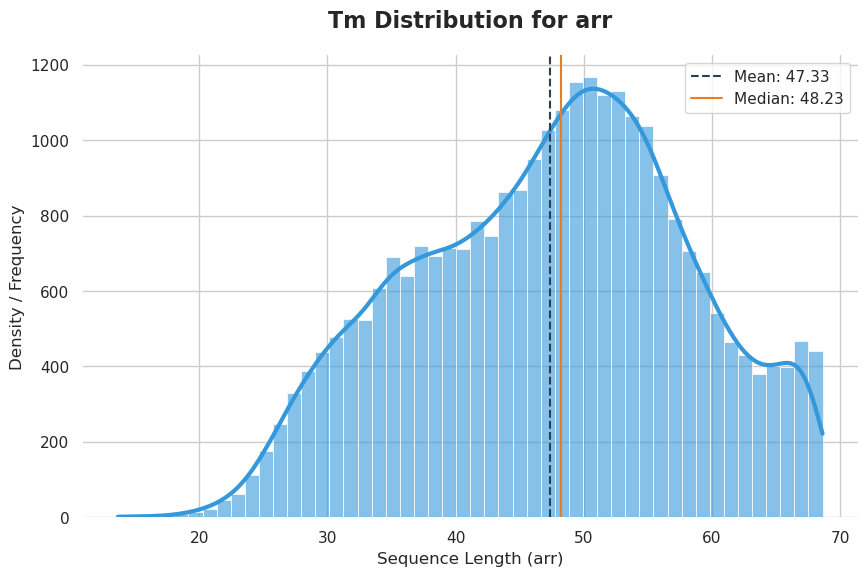

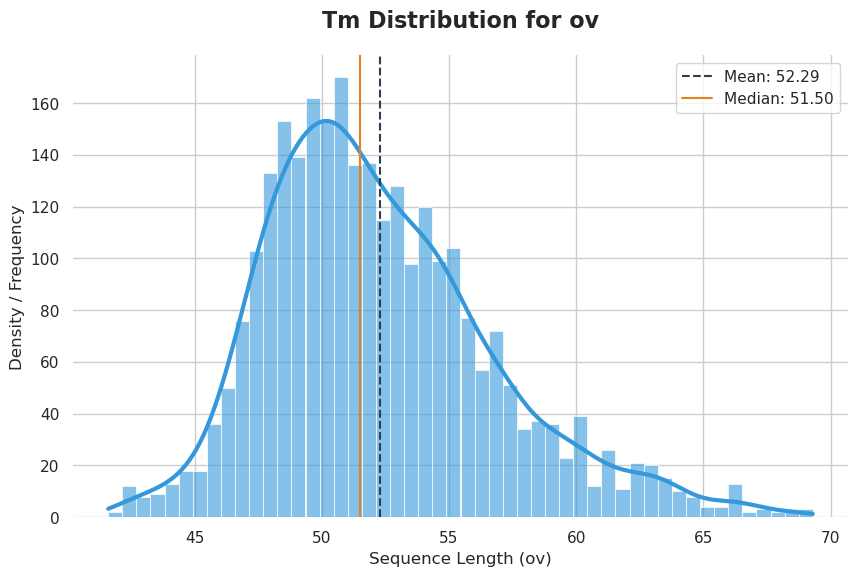

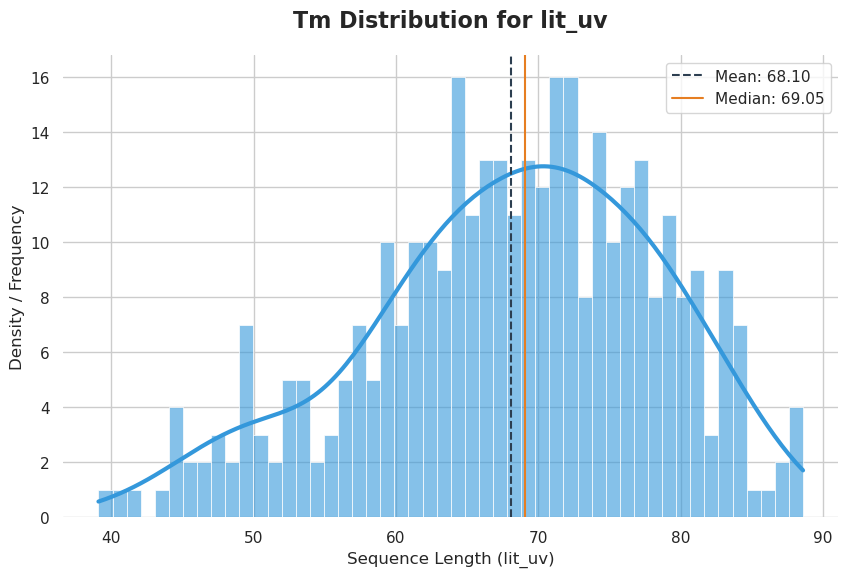

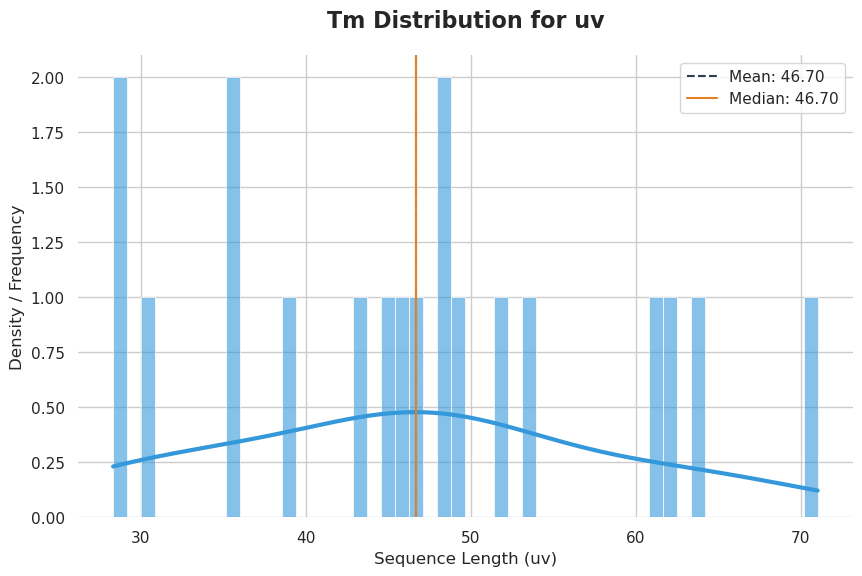

In [78]:
for dataset_name, dataset in zip(datasets, [df_arr, df_ov, df_lit_uv, df_uv]):
    seq = dataset['Tm']
    plot_histogram(seq, dataset_name, title=f'Tm Distribution for {dataset_name}', x_label='Tm')

Skipping ov: No dH data available
Skipping lit_uv: No dH data available


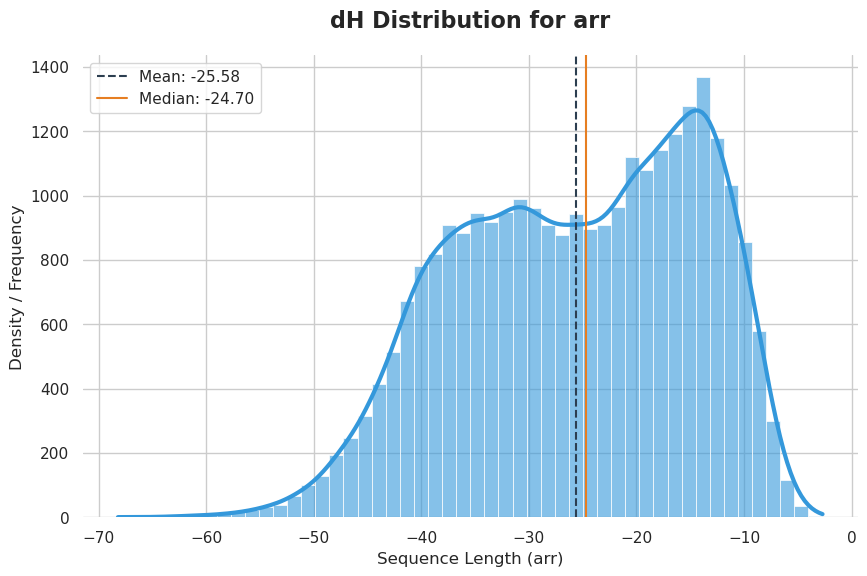

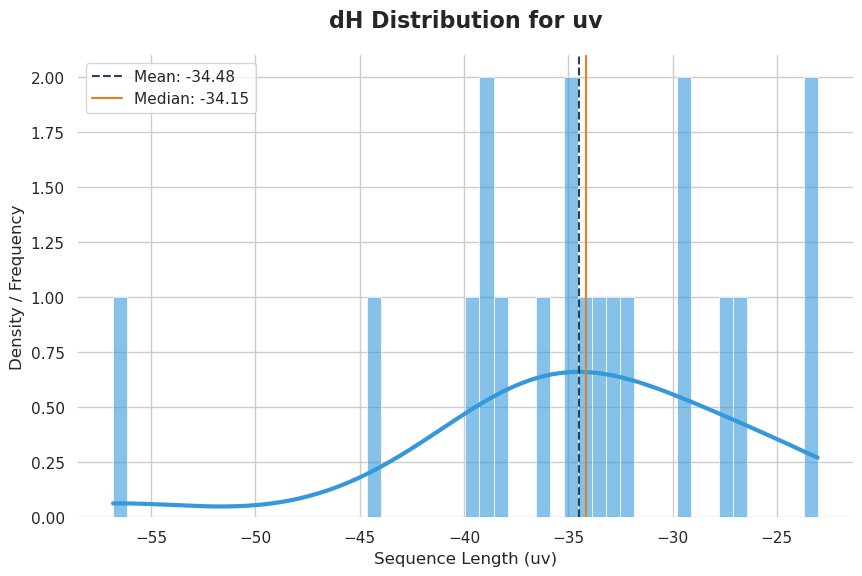

In [79]:
for dataset_name, dataset in zip(datasets, [df_arr, df_ov, df_lit_uv, df_uv]):
    seq = dataset['dH']
    if seq.isna().all():
        print(f"Skipping {dataset_name}: No dH data available")
        continue
    plot_histogram(seq, dataset_name, title=f'dH Distribution for {dataset_name}', x_label='dH')


    